# Preambolo

In [ ]:
import numpy as np
import matplotlib as mtp
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import math
import sys
from scipy.stats import norm
from scipy.stats import chi2
from matplotlib.ticker import FormatStrFormatter
from scipy import stats
from scipy.constants import g
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import StrMethodFormatter
!pip install uncertainties
from uncertainties import ufloat
import uncertainties.umath
from uncertainties.umath import sin
from uncertainties import unumpy as unp
from uncertainties.umath import sqrt
from uncertainties import ufloat


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 791.1 kB/s eta 0:00:00


In [ ]:
import os
import sys
import shutil

%cd /content/
if os.path.exists('/content/Esperienze-in-laboratorio'):
    shutil.rmtree('/content/Esperienze-in-laboratorio')

!git clone https://github.com/matteodeclich/Esperienze-in-laboratorio.git

percorso_libreria = '/content/Esperienze-in-laboratorio/Libreria_python'
if percorso_libreria not in sys.path:
    sys.path.insert(0, percorso_libreria)

try:
    from analisi_dati import *
    print("✅ Tutto pronto! Librerie installate e modulo importato.")
except Exception as e:
    print(f"❌ Errore durante l'import: {e}")

%cd Esperienze-in-laboratorio
%cd Corda

/content
Cloning into 'Esperienze-in-laboratorio'...
remote: Enumerating objects: 1438, done.
remote: Counting objects: 100% (345/345), done.
remote: Compressing objects: 100% (213/213), done.
remote: Total 1438 (delta 164), reused 302 (delta 123), pack-reused 1093 (from 1)
Receiving objects: 100% (1438/1438), 18.13 MiB | 19.61 MiB/s, done.
Resolving deltas: 100% (734/734), done.
✅ Tutto pronto! Librerie installate e modulo importato.
/content/Esperienze-in-laboratorio
/content/Esperienze-in-laboratorio/Corda


# Pull

In [ ]:
!git pull

Already up to date.


# f(Numero di Armonica)

In [ ]:
df=pd.read_excel('Corda.xlsx', sheet_name=0)
df=df.fillna('')
df

,Massa appesa [kg],n,f [Hz],sf [Hz],M supporto [kg],Mcorda [kg]
0,0.13048,1.0,20.0,0.5,0.08062,0.00522
1,,2.0,40.0,0.5,m1 [kg],sm [kg]
2,,3.0,60.0,0.5,0.00999,0.0005
3,,4.0,80.0,0.5,m2 [kg],L corda [m]
4,0.08062,1.0,16.0,0.5,0.01997,2.487
5,,2.0,32.5,0.5,m3 [kg],sL [m]
6,,3.0,48.0,0.5,0.19974,0.015
7,,4.0,63.5,0.5,Massa 4,μ
8,0.00999,1.0,17.0,0.5,0.04986,0.002099
9,,2.0,34.5,0.5,,Lunghezza tratto [m]


Il risultato del fit y = k0·x è:
  k0 = 17.266667±0.091287


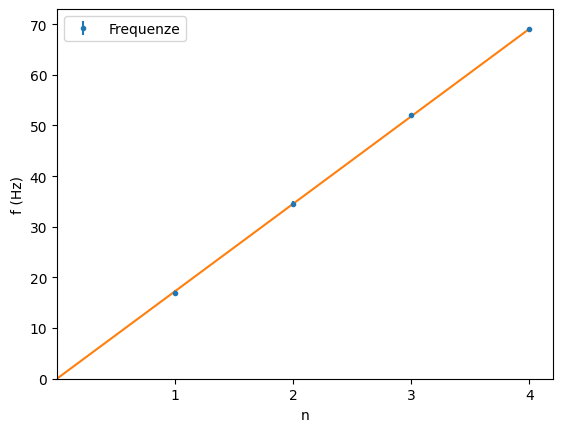

Il risultato del test del χ² è:
  χ²               = 0.46666667
  Gradi di libertà = 3
  χ² ridotto       = 0.15555556
  Il p-value associato è: 0.92615114
0.002099±0.000201
Il valore misurato di k è: 17.27±0.09
Il valore teorico di k è: 18.79±1.00
Test di compatibilità tra k sperimentale e k teorico: |t| = 1.5213386
Il valore misurato di v1 è: 22.68±0.53
Il valore teorico v1 è: 24.69±1.19
Test di compatibilità tra v_teo e v_exp: |t| = 1.543495


In [ ]:
nodi=df.iloc[:4, 1]
n=pd.to_numeric(nodi, errors='coerce').dropna().values
f=pd.to_numeric(df.iloc[8:12, 2], errors='coerce').dropna().values
sf=pd.to_numeric(df.iloc[8:12, 3], errors='coerce').dropna().values

k0 = minquadw_kx(n, f, sf, nome="k0")
def retta(x, k):
    return x * k
t = np.linspace(0, max(n), 100)

plt.errorbar(n, f, yerr=sf, fmt='o', ls='none', label='Frequenze', ms=3)
plt.plot(t, retta(t, k0.nominal_value))

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.xticks(n)
plt.xlabel(r'n')
plt.ylabel(r'f (Hz)')
plt.legend()
plt.show()

print("="*70)
chi_quadro(f, k0 * n, sf, 1)
print("="*70)

m = ufloat(df.iloc[0, 0], df.iloc[2, 5])
L_corda = ufloat(df.iloc[4, 5], df.iloc[12, 5])
m_corda = ufloat(df.iloc[0, 5], df.iloc[2, 5])
L_tratto = ufloat(df.iloc[10, 5], df.iloc[12, 5])
T = m * g
μ = m_corda / L_corda
k0_teo = (1 / (2 * L_tratto)) * sqrt((m * g * L_corda) / m_corda)
v0_teo = sqrt(T / μ)
v0 = 2 * L_tratto * k0

print(f"{μ:.4P}")
print(f"Il valore misurato di k è: {k0:.4P}")
print(f"Il valore teorico di k è: {k0_teo:.4P}")
t_test(k0, k0_teo, nome1="k sperimentale", nome2="k teorico")
print("="*70)

print(f"Il valore misurato di v1 è: {v0:.4P}")
print(f"Il valore teorico v1 è: {v0_teo:.4P}")
t_test(v0, v0_teo, nome1="v_teo", nome2="v_exp")
print("="*70)

# f(Tensione)

In [ ]:
df1=pd.read_excel('Corda.xlsx', sheet_name=1)
df1=df1.fillna('')
df1

,Massa appesa [kg],f [Hz],sf [Hz],M supporto [kg]
0,0.13048,40.0,1.0,0.08062
1,0.08062,32.0,1.0,m1 [kg]
2,0.09061,33.0,1.0,0.00999
3,0.11058,37.0,1.0,m2 [kg]
4,0.15045,42.0,1.0,0.01997
5,0.18034,47.0,1.0,m3 [kg]
6,0.28036,57.0,1.0,0.19974
7,0.38008,65.0,1.0,Massa 4
8,,,,0.04986


Il risultato del fit y = k·x è:
  k = 34.645975±0.269544


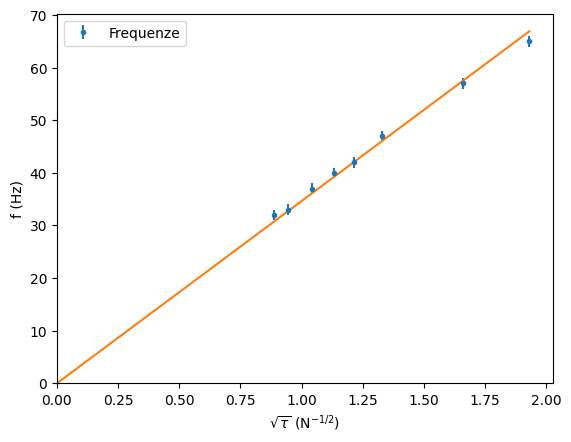

Il risultato del test del χ² è:
  χ²               = 7.6754929
  Gradi di libertà = 7
  χ² ridotto       = 1.096499
  Il p-value associato è: 0.36207617
Il valore sperimentale di k è: 34.65±0.27
Il valore teorico di k è: 33.23±1.77
Test di compatibilità tra k_exp e k_teo: |t| = 0.79384112


In [ ]:
masse=pd.to_numeric(df1.iloc[:, 0], errors='coerce').dropna().values
sm=df.iloc[2, 5]
m=unp.uarray(masse, sm)
f1=pd.to_numeric(df1.iloc[:, 1], errors='coerce').dropna().values
sf1=pd.to_numeric(df1.iloc[:, 2], errors='coerce').dropna().values
T=m*g
f_teoriche=(1/L_tratto)*unp.sqrt(T/μ)

x = unp.nominal_values(unp.sqrt(T))
k1= minquadw_kx(x, f1, sf1)
t = np.linspace(0, max(x), 100)

plt.errorbar(x, f1, yerr=sf1, fmt='o', ls='none', label='Frequenze', ms=3)
plt.plot(t, retta(t, k1.nominal_value))

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.xlabel(r'$\sqrt{\tau}$ ($\text{N}^{-1/2}$)')
plt.ylabel(r'f (Hz)')
plt.legend()
plt.show()

print("="*70)
chi_quadro(f1, k1*x, sf1, 1)
print("="*70)

print(f"Il valore sperimentale di k è: {k1:.4P}")
k1_teo = 1/(L_tratto*sqrt(μ))
print(f"Il valore teorico di k è: {k1_teo:.4P}")
print("="*70)

t_test(k1, k1_teo, nome1="k_exp", nome2="k_teo")
print("="*70)

# f(Lunghezza)

In [ ]:
df2=pd.read_excel('Corda.xlsx', sheet_name=2)
df2=df2.fillna('')
df2

,Massa fissa [kg],L [m],f [Hz],sf [Hz],M supporto [kg],M corda [kg],dL [m]
0,0.19974,0.657,57.0,0.5,0.08062,0.00522,0.0072
1,,0.822,46.0,0.5,m fissa [kg],sM corda [kg],μ'
2,,0.542,69.0,0.5,0.19974,0.0005,0.002093
3,,0.411,92.0,0.5,Mtot [kg],Lunghezza corda [m],
4,,0.966,39.0,0.5,0.28036,2.487,
5,,1.123,33.0,0.5,sM [kg],sL [m],
6,,,,,0.0005,0.015,
7,,,,,,μ,
8,,,,,,0.002099,


Il risultato del fit y = k·x è:
  k = 37.612122±0.129163


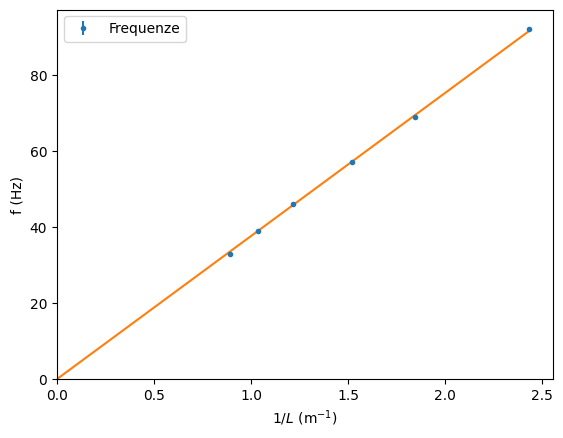

Il risultato del test del χ² è:
  χ²               = 3.0401997
  Gradi di libertà = 5
  χ² ridotto       = 0.60803995
  Il p-value associato è: 0.6937881
Il valore sperimentale di k è: 37.61±0.13
Il valore teorico di k è: 36.19±1.74
Test di compatibilità tra v_exp e v_teo: |t| = 0.8148713
Il valore di v considerando dL  è: 36.25±1.74
Test di compatibilità tra v_exp e v_: |t| = 0.78369815


In [ ]:
Ln=pd.to_numeric(df2.iloc[:, 1], errors='coerce').dropna().values
f2=pd.to_numeric(df2.iloc[:, 2], errors='coerce').dropna().values
sf2=pd.to_numeric(df2.iloc[:, 3], errors='coerce').dropna().values

x=1/Ln
k2=minquadw_kx(x, f2, sf2)
t = np.linspace(0, max(x), 100)

plt.errorbar(x, f2, yerr=sf2, fmt='o', ls='none', label='Frequenze', ms=3)
plt.plot(t, retta(t, k2.nominal_value))

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.xlabel(r'$1/L$ $(\text{m}^{-1})$')
plt.ylabel(r'f (Hz)')
plt.legend()
plt.show()

print("="*70)
chi_quadro(f2, k2 * x, sf2, 1)
print("="*70)

print(f"Il valore sperimentale di k è: {k2:.4P}")
m2= ufloat(df2.iloc[4, 4], 0.0005)
T2 = g*m2
v2_teo = sqrt(T2/μ)
print(f"Il valore teorico di k è: {v2_teo:.4P}")
print("="*70)
t_test(k2, v2_teo, nome1="v_exp", nome2="v_teo")
print("="*70)
v_ = sqrt(T2 * (L_corda+ 0.0072)/m_corda)
print(f"Il valore di v considerando dL  è: {v_:.4P}")
print("="*70)
t_test(k2, v_, nome1="v_exp", nome2="v_")
print("="*70)

# f(Massa Lineare)

In [ ]:
df3=pd.read_excel('Corda.xlsx', sheet_name=3)
df3=df3.fillna('')
df3

,Unnamed: 0,m [kg],L [m],μ [kg/m],f [Hz],sf [Hz],Massa supporto (kg)
0,Corda verde fluo,0.00333,1.46,0.002281,52.0,0.5,0.08062
1,Corda gialla e nera,0.00585,2.47,0.002368,51.0,0.5,Massa fissa
2,Corda nera,0.00505,2.5,0.00202,55.0,0.5,0.19974
3,Corda rossa,0.00522,2.487,0.002099,54.0,0.5,Distanza fissa (m)
4,Corda viola,0.00407,1.75,0.002326,53.0,0.5,0.697
5,,,,,,,Incertezza distanza fissa (m)
6,,,,,,,0.015
7,,,,,,,Massa totale (kg)
8,,,,,,,0.28036
9,,,,,,,Incertezza sulla massa


Il risultato del fit y = k·x è:
  k = 2.4775248±0.0116813


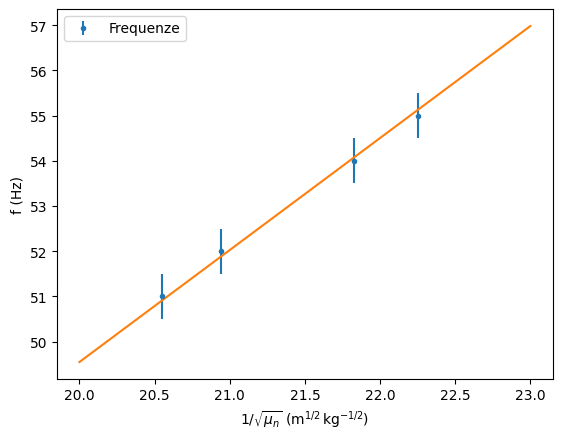

Il risultato del test del χ² è:
  χ²               = 0.18049718
  Gradi di libertà = 3
  χ² ridotto       = 0.060165726
  Il p-value associato è: 0.98067456
Il valore sperimentale di k è: 2.478±0.012
Il valore teorico di k è: 2.379±0.051
Test di compatibilità tra k_exp e k_teo: |t| = 1.8756052


In [ ]:
μ_n=pd.to_numeric(df3.iloc[0:4, 3], errors='coerce').dropna().values
f3=pd.to_numeric(df3.iloc[0:4, 4], errors='coerce').dropna().values
sf3=pd.to_numeric(df3.iloc[0:4, 5], errors='coerce').dropna().values
x=1/np.sqrt(μ_n)

k3=minquadw_kx(x, f3, sf3)
t = np.linspace(20, 23)
plt.errorbar(x, f3, yerr=sf3, fmt='o', ls='none', label='Frequenze', ms=3)
plt.plot(t, retta(t, k3.nominal_value))

plt.xlabel(r'1/$\sqrt{\mu_{n}}$ $(\text{m}^{1/2}\,\text{kg}^{-1/2})$')
plt.ylabel(r'f (Hz)')
plt.legend()
plt.show()

print("="*70)
chi_quadro(f3, k3 * x, sf3, 1)
print("="*70)

print(f"Il valore sperimentale di k è: {k3:.4P}")
m3=ufloat(df3.iloc[8, 6], df3.iloc[10, 6])
T3=g*m3
L3=ufloat(df3.iloc[4, 6], df3.iloc[6, 6])
k3_teo=sqrt(T3)/L3
print(f"Il valore teorico di k è: {k3_teo:.4P}")
print("="*70)

t_test(k3, k3_teo, nome1="k_exp", nome2="k_teo")
print("="*70)